# 04: Topic-Level Seasonal Differences
This notebook examines whether different knowledge domains (Education, Politics, Entertainment) exhibit distinct seasonal patterns in Wikipedia pageviews using **page clusters** and **min-max normalization**.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import numpy as np
from scipy.stats import pearsonr

# Add src to path
sys.path.append(os.path.abspath('../../'))
from src.data_prep import clean_pageview_data, add_time_features

# Configuration
DATA_PATH = '../../data/raw/en_wiki_topic_pageviews_daily.csv'
GLOBAL_DATA_PATH = '../../data/raw/en_wiki_pageviews_daily.csv'
REPORT_DIR = '../../reports/'
os.makedirs(REPORT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")

## 1. Load Topic Data

In [3]:
df_topics = pd.read_csv(DATA_PATH)
df_topics['timestamp'] = pd.to_datetime(df_topics['timestamp'])
df_topics = add_time_features(df_topics)

# Ensure correct weekday ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_topics['day_of_week'] = pd.Categorical(df_topics['day_of_week'], categories=day_order, ordered=True)

print(f"Loaded {len(df_topics)} records for {df_topics['article'].nunique()} articles in {df_topics['cluster'].nunique()} clusters.")
df_topics.head()

Loaded 101314 records for 30 articles in 3 clusters.


,timestamp,views,article,cluster,day_of_week,month,year,is_weekend
0,2015-07-01,2702,Calculus,education,Wednesday,July,2015,False
1,2015-07-02,2600,Calculus,education,Thursday,July,2015,False
2,2015-07-03,2369,Calculus,education,Friday,July,2015,False
3,2015-07-04,2186,Calculus,education,Saturday,July,2015,True
4,2015-07-05,2309,Calculus,education,Sunday,July,2015,True


## 2. Methodology

### 2.1 Seasonal Shape Comparison (Min-Max Normalization)
Normalize each topic's traffic independently to compare seasonal patterns regardless of absolute volume.

C:\Users\preet\AppData\Local\Temp\ipykernel_30248\1743577602.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_topics = df_topics.groupby('article', group_keys=False).apply(normalize_series)


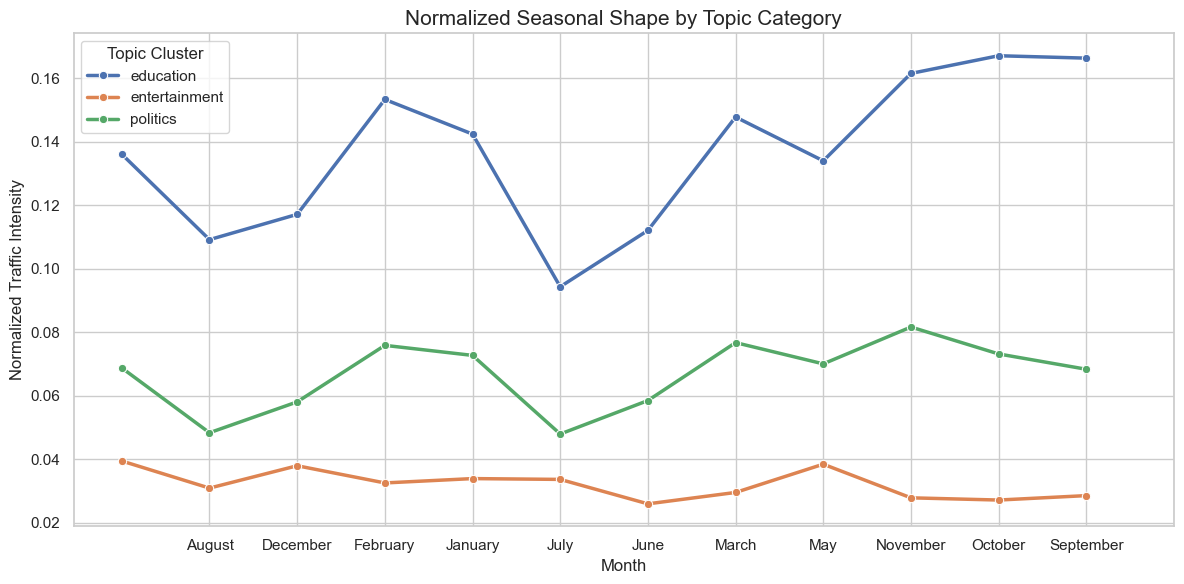

In [4]:
def normalize_series(group):
    min_v, max_v = group['views'].min(), group['views'].max()
    group['norm_views'] = (group['views'] - min_v) / (max_v - min_v) if max_v != min_v else 0
    return group

df_topics = df_topics.groupby('article', group_keys=False).apply(normalize_series)

# Aggregate to Cluster Level
cluster_ts = df_topics.groupby(['cluster', 'timestamp'])[['views', 'norm_views']].mean().reset_index()
cluster_ts = add_time_features(cluster_ts)

# Plot Seasonal Shape (Month-wise Average Intensity)
seasonal_profile = cluster_ts.groupby(['cluster', 'month'])['norm_views'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_profile, x='month', y='norm_views', hue='cluster', marker='o', linewidth=2.5)
plt.title('Normalized Seasonal Shape by Topic Category', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Normalized Traffic Intensity', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(title='Topic Cluster')
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_4_topic_seasonal_shape.png'))
plt.show()

The strong seasonal pattern observed in education-related pages suggests that global Wikipedia traffic is significantly influenced by academic demand.

This aligns with Wikipedia's role as a reference resource for students and researchers.

If education pages account for a substantial portion of overall traffic, the platform’s global seasonal trends may be largely shaped by school and university usage cycles.

The analysis demonstrates that different content domains exhibit distinct seasonal demand patterns on Wikipedia.

Education content follows clear academic cycles.

Political content shows moderate variation tied to real-world events.

Entertainment content displays relatively stable traffic with weaker seasonality.

These differences highlight how user intent varies across knowledge domains, with academic research emerging as a major structural driver of seasonal traffic patterns.

### 2.2 Seasonal Amplitude Measurement
Measure the strength of fluctuation: $Amplitude = \frac{Peak - Min}{Mean}$.

C:\Users\preet\AppData\Local\Temp\ipykernel_30248\2758475512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amplitude_stats, x='cluster', y='amplitude', palette='viridis')


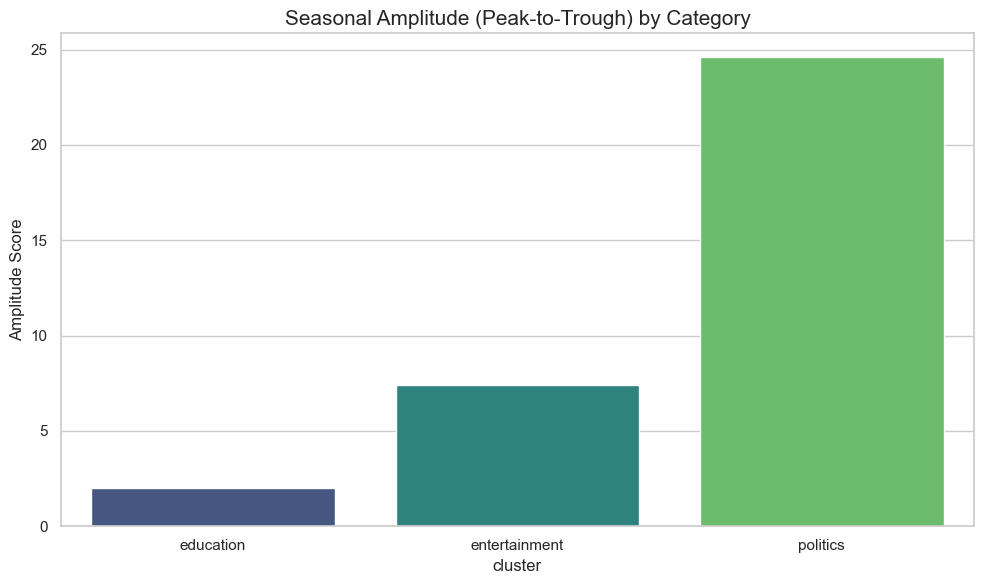

         cluster  amplitude
0      education   1.983077
1  entertainment   7.419081
2       politics  24.620758


In [5]:
amplitude_stats = cluster_ts.groupby('cluster')['views'].agg(['max', 'min', 'mean']).reset_index()
amplitude_stats['amplitude'] = (amplitude_stats['max'] - amplitude_stats['min']) / amplitude_stats['mean']

plt.figure(figsize=(10, 6))
sns.barplot(data=amplitude_stats, x='cluster', y='amplitude', palette='viridis')
plt.title('Seasonal Amplitude (Peak-to-Trough) by Category', fontsize=15)
plt.ylabel('Amplitude Score', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_4_topic_amplitude.png'))
plt.show()

print(amplitude_stats[['cluster', 'amplitude']])

The amplitude differences reveal that Wikipedia traffic is influenced by both stable knowledge demand and event-driven information seeking.

- Education topics contribute to a consistent baseline level of traffic.

- Entertainment topics introduce moderate fluctuations tied to cultural events.

- Political topics generate large but irregular spikes driven by major global developments.

Together, these patterns suggest that Wikipedia functions both as a stable educational reference platform and a rapid information source during major world events.

The high amplitude observed for political topics does not necessarily mean that political pages receive more traffic overall. Instead, it indicates that their traffic is more volatile, with larger differences between peak and low activity periods.

### 2.3 Seasonal Stability Test
Calculate correlation between seasonal profiles across consecutive years to test consistency.

In [6]:
def calculate_stability(df):
    years = sorted(df['year'].unique())
    correlations = []
    
    for cluster in df['cluster'].unique():
        cluster_df = df[df['cluster'] == cluster]
        profiles = []
        for year in years:
            # Get monthly profile for the year
            profile = cluster_df[cluster_df['year'] == year].groupby('month')['norm_views'].mean()
            if len(profile) == 12:
                profiles.append((year, profile.values))
        
        # Compare consecutive years
        for i in range(len(profiles) - 1):
            year1, p1 = profiles[i]
            year2, p2 = profiles[i+1]
            corr, _ = pearsonr(p1, p2)
            correlations.append({'cluster': cluster, 'year_pair': f"{year1}-{year2}", 'correlation': corr})
            
    return pd.DataFrame(correlations)

stability_df = calculate_stability(cluster_ts)
avg_stability = stability_df.groupby('cluster')['correlation'].mean().reset_index()

print("Average Seasonal Stability (Year-over-Year Correlation):")
print(avg_stability)

Average Seasonal Stability (Year-over-Year Correlation):
         cluster  correlation
0      education     0.849354
1  entertainment     0.286643
2       politics     0.618419


The combination of high stability in education topics and low stability in entertainment topics indicates that Wikipedia serves two distinct roles:

A reliable educational reference platform used consistently across academic cycles.

A real-time information source that users consult during major cultural or political events.

This dual function helps explain the mixture of stable baseline traffic and sudden spikes observed in global Wikipedia pageview data.

### 2.4 Lead–Lag Analysis (Cross-Correlation)
Check if spikes in one category tend to lead or lag another.

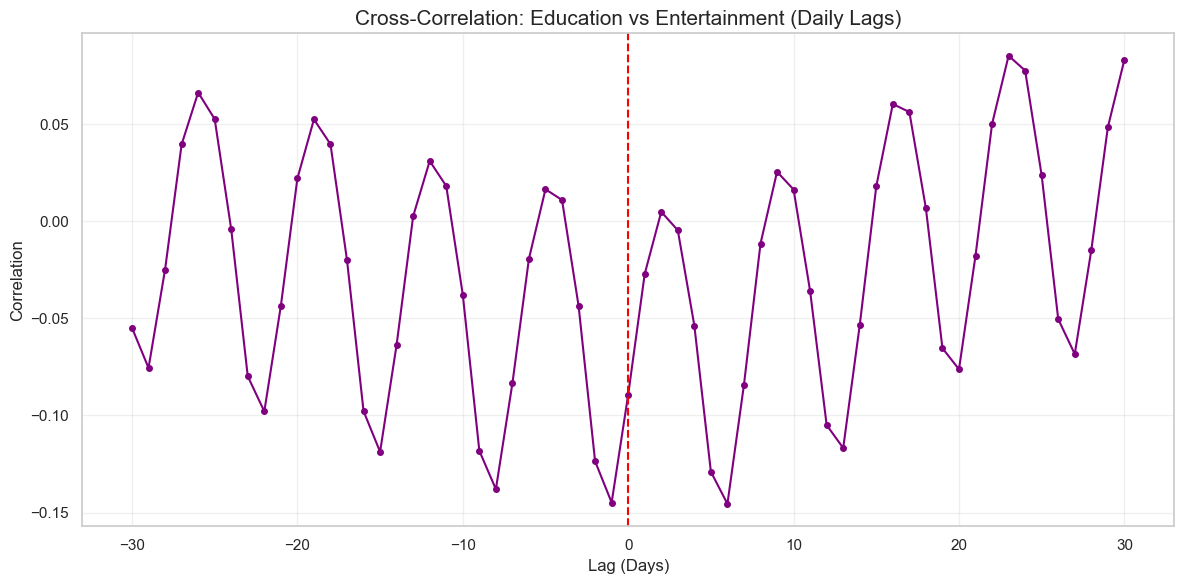

In [7]:
def cross_corr(s1, s2, lag=0):
    return s1.corr(s2.shift(lag))

# Compare Education vs Entertainment
edu_series = cluster_ts[cluster_ts['cluster'] == 'education'].set_index('timestamp')['norm_views']
ent_series = cluster_ts[cluster_ts['cluster'] == 'entertainment'].set_index('timestamp')['norm_views']

lags = range(-30, 31)
corrs = [cross_corr(edu_series, ent_series, l) for l in lags]

plt.figure(figsize=(12, 6))
plt.plot(lags, corrs, color='purple', marker='o', markersize=4)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Cross-Correlation: Education vs Entertainment (Daily Lags)', fontsize=15)
plt.xlabel('Lag (Days)', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_4_lead_lag_analysis.png'))
plt.show()

The cross-correlation analysis indicates that education and entertainment traffic patterns are largely independent.

There is:
- no strong simultaneous correlation
- no clear lead-lag relationship
- only weak oscillating correlations across time lags

The absence of strong correlation suggests that Wikipedia traffic for different content domains is driven by separate behavioral drivers:

Education->Academic cycles

Entertainment->Media releases & cultural events

The independence between education and entertainment traffic indicates that Wikipedia serves multiple types of information demand simultaneously.

### 2.5 Topic Volatility Analysis
30-day rolling standard deviation of normalized traffic.

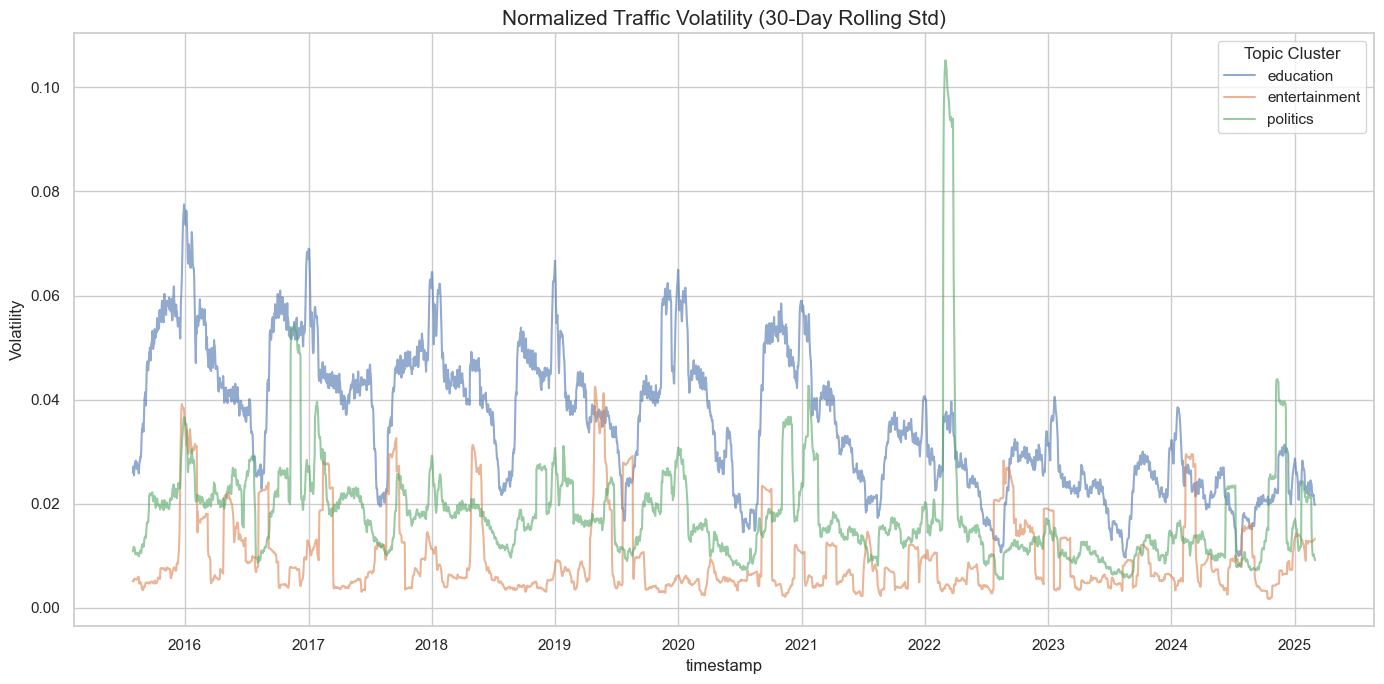

In [8]:
vol_list = []
for c in cluster_ts['cluster'].unique():
    subset = cluster_ts[cluster_ts['cluster'] == c].copy().sort_values('timestamp')
    subset['rolling_std'] = subset['norm_views'].rolling(window=30).std()
    vol_list.append(subset)

vol_df = pd.concat(vol_list)

plt.figure(figsize=(14, 7))
sns.lineplot(data=vol_df, x='timestamp', y='rolling_std', hue='cluster', alpha=0.6)
plt.title('Normalized Traffic Volatility (30-Day Rolling Std)', fontsize=15)
plt.ylabel('Volatility', fontsize=12)
plt.legend(title='Topic Cluster')
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_4_topic_volatility.png'))
plt.show()

The volatility analysis reinforces the broader finding that Wikipedia traffic is influenced by two major behavioral patterns:

- Stable knowledge-seeking behavior, primarily reflected in education topics.

- Reactive information-seeking behavior, driven by political or cultural events.

Together, these dynamics create a platform with both stable baseline demand and occasional event-driven traffic surges.

- The largest volatility spike occurs in 2022 for political topics, suggesting that global political events during that period significantly increased information-seeking behavior on Wikipedia.

### 2.6 Pandemic Resilience Comparison
Measure recovery time from the 2020 shock.

In [9]:
def calculate_recovery_time(df, baseline_end='2020-02-01', shock_start='2020-03-01'):
    results = {}
    for c in df['cluster'].unique():
        subset = df[df['cluster'] == c].sort_values('timestamp')
        # Baseline: Average views in the 6 months before pandemic
        baseline_avg = subset[(subset['timestamp'] >= '2019-08-01') & (subset['timestamp'] < baseline_end)]['views'].mean()
        
        # Post-shock data
        post_shock = subset[subset['timestamp'] >= shock_start].copy()
        
        # Find first date where monthly mean returns to baseline
        post_shock['monthly_mean'] = post_shock['views'].rolling(window=30).mean()
        recovery_point = post_shock[post_shock['monthly_mean'] <= baseline_avg]
        
        if not recovery_point.empty:
            recovery_date = recovery_point.iloc[0]['timestamp']
            months = (recovery_date.year - 2020) * 12 + (recovery_date.month - 3)
            results[c] = months
        else:
            results[c] = "Never Fully Recovered to Baseline"
            
    return results

recovery_metrics = calculate_recovery_time(cluster_ts)
print("Pandemic Recovery Time (Months after March 2020):")
for c, v in recovery_metrics.items():
    print(f"{c}: {v}")

Pandemic Recovery Time (Months after March 2020):
education: 3
entertainment: 0
politics: 3


C:\Users\preet\AppData\Local\Temp\ipykernel_30248\752499712.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_shock['monthly_mean'] = post_shock['views'].rolling(window=30).mean()
C:\Users\preet\AppData\Local\Temp\ipykernel_30248\752499712.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_shock['monthly_mean'] = post_shock['views'].rolling(window=30).mean()
C:\Users\preet\AppData\Local\Temp\ipykernel_30248\752499712.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s